# Async CUDA Profiling with Nsight Systems
Profiling multiple streams and kernels using `nsys` in Colab.

In [2]:
# 1) 克隆仓库
import os
if not os.path.exists('/content/ops'):
    # TODO: replace with your fork URL after pushing
    !git clone https://github.com/hswsp/learn-cuda-from-scratch.git /content/ops
%cd /content/ops

Cloning into '/content/ops'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (251/251), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 251 (delta 69), reused 211 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (251/251), 271.70 KiB | 5.91 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/ops


### 验证安装

In [4]:
# 单元格1：安装 Nsight Systems（Colab 默认未安装）
!apt-get update -qq && apt-get install -y -qq nvidia-nsight-systems 2>&1 | tail -5

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Unable to locate package nvidia-nsight-systems


In [5]:
# Colab已经装了好像
!find /usr /opt -name nsys -type f 2>/dev/null

/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/nsys


In [6]:
!/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/nsys --version

NVIDIA Nsight Systems version 2025.1.1.0


In [13]:
# 临时加 PATH
import os
os.environ['PATH'] = '/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64:' + os.environ['PATH']
!nsys --version

NVIDIA Nsight Systems version 2025.1.1.0


### 编译

In [3]:
# 2) 编译并跑通第 8 章 async
%cd /content/ops
!make -C code/ch08_async ARCH='sm_75' clean all run

/content/ops
make: Entering directory '/content/ops/code/ch08_async'
rm -f multi_stream cuda_graph_demo
nvcc -O2 -std=c++17 -arch=sm_75 -lineinfo multi_stream.cu -o multi_stream
nvcc -O2 -std=c++17 -arch=sm_75 -lineinfo cuda_graph_demo.cu -o cuda_graph_demo
serial    : 5.226 ms
4 streams: 2.610 ms  (2.00x)

1000 separate launches : 3.996 ms (4.00 us/launch)
cuda graph (1 launch): 1.870 ms (2.14x faster)
make: Leaving directory '/content/ops/code/ch08_async'


### 运行 nsys profile

In [15]:
%cd /content/ops
!ls -lh ./code/ch08_async/multi_stream

/content/ops
-rwxr-xr-x 1 root root 988K Jul 15 08:58 ./code/ch08_async/multi_stream


In [17]:
!nsys profile --trace=cuda --output=./code/ch08_async/report --force-overwrite=true --gpu-metrics-devices=none ./code/ch08_async/multi_stream 2>&1 | tail -15

Invalid plugin configuration: Executable path does not exist: /opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/plugins/efa_metrics/nic_sampler
serial    : 5.260 ms
4 streams: 3.126 ms  (1.68x)
Generating '/tmp/nsys-report-645e.qdstrm'
[1/1] [========================100%] report.nsys-rep
Generated:
    /content/ops/./code/ch08_async/report.nsys-rep


In [19]:
!ls -lh /content/ops/code/ch08_async/report.nsys-rep 2>/dev/null || ls -lh ./code/ch08_async/report*

-rw-rw-r-- 1 root root 75K Jul 15 09:11 /content/ops/code/ch08_async/report.nsys-rep


### 导出 SQLite 数据库

In [20]:
!nsys export ./code/ch08_async/report.nsys-rep --output=./code/ch08_async/report.sqlite --type=sqlite 2>&1 | tail -5

Processing 541 events: [===================================================100%]


### 查询 Profiling 结果

In [31]:
import sqlite3
conn = sqlite3.connect('./code/ch08_async/report.sqlite')
cursor = conn.cursor()

# 1. Kernel 信息（使用 end - start 代替 dur）
# 查看表结构
#cursor.execute("PRAGMA table_info(CUPTI_ACTIVITY_KIND_KERNEL)")
#columns = cursor.fetchall()
#print("Columns in CUPTI_ACTIVITY_KIND_KERNEL:")
#for col in columns:
#    print(col)

print("=== KERNELS ===")
cursor.execute("""
    SELECT demangledName,
           CAST(AVG(end - start) AS REAL) / 1e6 AS avg_ms,
           COUNT(*) AS calls
    FROM CUPTI_ACTIVITY_KIND_KERNEL
    GROUP BY demangledName
""")
rows = cursor.fetchall()
print(f"{'Kernel Name':<45} {'Avg Time (ms)':<20} {'Calls':<10}")
print("-"*80)
for row in rows:
    print(f"{row[0]:<45} {row[1]:<20.4f} {row[2]:<10}")

# 2. 先查看 memcpy 表中有哪些不同的 copyKind 值（以便了解枚举含义）
cursor.execute("SELECT DISTINCT copyKind FROM CUPTI_ACTIVITY_KIND_MEMCPY")
copy_kinds = [row[0] for row in cursor.fetchall()]
print(f"\nDistinct copyKind values: {copy_kinds}")

# 3. Memory Copies 信息（按 copyKind 分组）
# 查看 memcpy 表结构
#cursor.execute("PRAGMA table_info(CUPTI_ACTIVITY_KIND_MEMCPY)")
#print("\n--- Memcpy Table Columns ---")
#for col in cursor.fetchall():
#    print(col)
print("\n=== MEMORY COPIES ===")
cursor.execute("""
    SELECT copyKind,
           CAST(AVG(end - start) AS REAL) / 1e6 AS avg_ms,
           SUM(bytes) AS total_bytes,
           COUNT(*) AS calls
    FROM CUPTI_ACTIVITY_KIND_MEMCPY
    GROUP BY copyKind
""")
rows = cursor.fetchall()
print(f"{'Copy Kind':<15} {'Avg Time (ms)':<20} {'Total Bytes':<20} {'Calls':<10}")
print("-"*70)
for row in rows:
    kind = row[0]
    # 常见枚举值（Nsight Systems 2025 可能略有不同，但大致如此）
    kind_name = {0: 'H2D', 1: 'D2H', 2: 'D2D'}.get(kind, f'Unknown({kind})')
    print(f"{kind_name:<15} {row[1]:<20.4f} {row[2]:<20} {row[3]:<10}")

# 4. 按 streamId 查看 kernel 分布（诊断多流重叠情况）
print("\n=== KERNELS PER STREAM ===")
cursor.execute("""
    SELECT streamId, demangledName,
           COUNT(*) AS calls,
           CAST(AVG(end - start) AS REAL) / 1e6 AS avg_ms,
           CAST(MIN(end - start) AS REAL) / 1e6 AS min_ms,
           CAST(MAX(end - start) AS REAL) / 1e6 AS max_ms
    FROM CUPTI_ACTIVITY_KIND_KERNEL
    GROUP BY streamId, demangledName
    ORDER BY streamId
""")
for row in cursor.fetchall():
    print(f"Stream {row[0]:2d}: {row[1]:<35} calls={row[2]:2d} avg={row[3]:.4f}ms min={row[4]:.4f}ms max={row[5]:.4f}ms")

conn.close()

=== KERNELS ===
Kernel Name                                   Avg Time (ms)        Calls     
--------------------------------------------------------------------------------
50                                            0.9787               5         

Distinct copyKind values: [1, 2]

=== MEMORY COPIES ===
Copy Kind       Avg Time (ms)        Total Bytes          Calls     
----------------------------------------------------------------------
D2H             0.5604               33554432             5         
D2D             0.5235               33554432             5         

=== KERNELS PER STREAM ===
Stream  7: 50                                  calls= 1 avg=2.4111ms min=2.4111ms max=2.4111ms
Stream 13: 50                                  calls= 1 avg=0.6083ms min=0.6083ms max=0.6083ms
Stream 14: 50                                  calls= 1 avg=0.6229ms min=0.6229ms max=0.6229ms
Stream 15: 50                                  calls= 1 avg=0.6229ms min=0.6229ms max=0.6229ms
Stre

All categories found: {'kernel', 'D2D', 'D2H'}


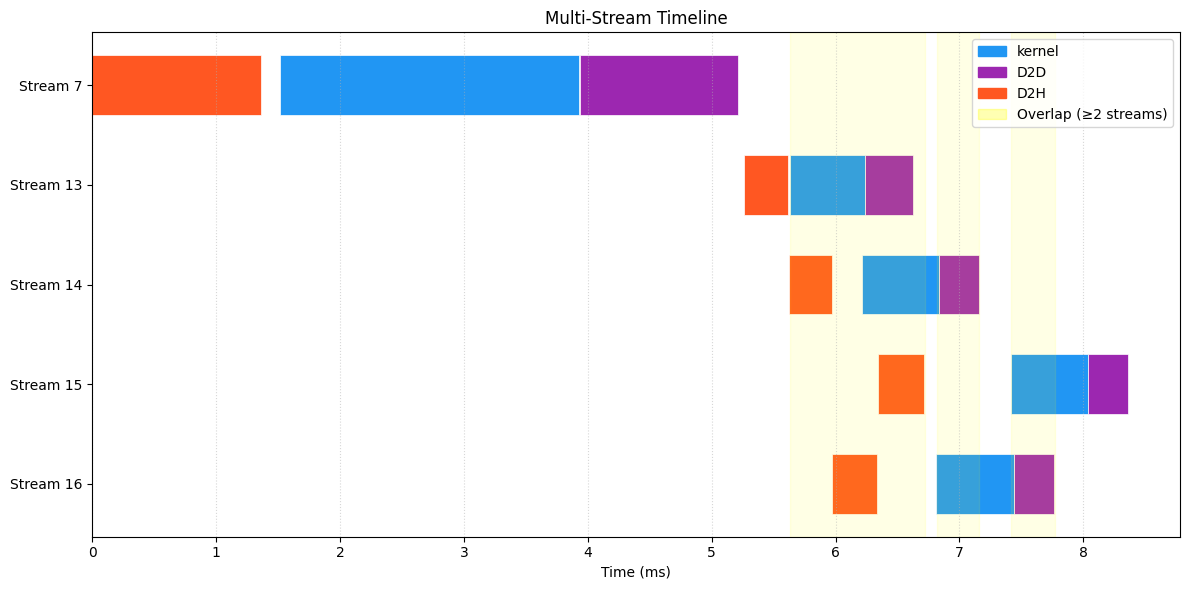

In [32]:
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. 连接数据库
conn = sqlite3.connect('./code/ch08_async/report.sqlite')
cursor = conn.cursor()

# 2. 提取所有事件
cursor.execute("SELECT start, end, streamId, demangledName, 'kernel' as typ FROM CUPTI_ACTIVITY_KIND_KERNEL")
kernels = cursor.fetchall()
cursor.execute("SELECT start, end, streamId, copyKind, 'memcpy' as typ FROM CUPTI_ACTIVITY_KIND_MEMCPY")
memcpies = cursor.fetchall()
conn.close()

all_events = list(kernels) + list(memcpies)
if not all_events:
    print("No events")
    exit()

# 3. 时间归一化
min_start = min(e[0] for e in all_events)

def classify(ev):
    start_ns, end_ns, streamId, extra, typ = ev
    start_ms = (start_ns - min_start) / 1e6
    dur_ms   = (end_ns - start_ns) / 1e6
    if typ == 'kernel':
        label = extra  # demangledName
        category = 'kernel'
    else:
        # copyKind: 0=H2D, 1=D2H, 2=D2D, 其他未知
        ck = extra
        if ck == 0:
            label = 'H2D'; category = 'H2D'
        elif ck == 1:
            label = 'D2H'; category = 'D2H'
        elif ck == 2:
            label = 'D2D'; category = 'D2D'
        else:
            label = f'memcpy({ck})'; category = f'memcpy({ck})'
    return (start_ms, dur_ms, streamId, label, category)

events = [classify(e) for e in all_events]

# 4. 查看所有出现的类别（打印出来方便排查）
categories = set(e[4] for e in events)
print("All categories found:", categories)

# 5. 为每个类别分配颜色（如果已有映射则沿用，未知的随机分配）
known_colors = {
    'H2D': '#4CAF50',
    'D2H': '#FF5722',
    'D2D': '#9C27B0',
    'kernel': '#2196F3',
}
# 为未知类别生成颜色
other_colors = ['#795548','#607D8B','#FF9800','#00BCD4','#E91E63','#3F51B5']
used_colors = {}
next_color_idx = 0
for cat in categories:
    if cat in known_colors:
        used_colors[cat] = known_colors[cat]
    else:
        if next_color_idx < len(other_colors):
            used_colors[cat] = other_colors[next_color_idx]
            next_color_idx += 1
        else:
            used_colors[cat] = '#888888'  # fallback gray

# 6. 绘图
streams = sorted(set(e[2] for e in events))
num_streams = len(streams)
fig, ax = plt.subplots(figsize=(12, 2 + 0.8*num_streams))

for idx, sid in enumerate(streams):
    y_pos = num_streams - idx - 1
    stream_events = [e for e in events if e[2] == sid]
    for start_ms, dur_ms, _, label, cat in stream_events:
        # 简化显示：kernel 显示为 'kernel'，memcpy 显示其类别
        display = 'kernel' if cat == 'kernel' else cat
        ax.barh(y_pos, dur_ms, left=start_ms, height=0.6,
                color=used_colors[cat], edgecolor='white', linewidth=0.5,
                label=display if idx==0 else "")

# 7. 自动检测重叠区（同之前）
overlap_regions = []
time_step = 0.01  # ms
t = 0.0
total_time = (max(e[0] for e in all_events) - min_start) / 1e6
while t < total_time:
    active = set()
    for start_ms, dur_ms, sid, _, _ in events:
        if start_ms <= t < start_ms + dur_ms:
            active.add(sid)
    if len(active) >= 2:
        if overlap_regions and overlap_regions[-1][1] >= t - time_step*1.5:
            overlap_regions[-1] = (overlap_regions[-1][0], t + time_step)
        else:
            overlap_regions.append((t, t + time_step))
    t += time_step

for (x0, x1) in overlap_regions:
    ax.axvspan(x0, x1, alpha=0.1, color='yellow')

# 8. 图例（包含所有类别）
ax.set_yticks(list(range(num_streams)))
ax.set_yticklabels([f'Stream {s}' for s in reversed(streams)])
ax.set_xlabel('Time (ms)')
ax.set_title('Multi-Stream Timeline')
ax.grid(axis='x', linestyle=':', alpha=0.5)

handles = []
for cat, color in used_colors.items():
    handles.append(mpatches.Patch(color=color, label=cat))
handles.append(mpatches.Patch(color='yellow', alpha=0.3, label='Overlap (≥2 streams)'))
ax.legend(handles=handles, loc='upper right')

plt.tight_layout()
plt.show()